# Sensor loss and training completeness

Two panels of one `figure*`:

- **(a)** how far a trained policy still walks when one modality is dropped at
  test time, against the un-ablated baseline;
- **(b)** an UpSet plot of how many policies ever learned to walk from each
  sensor subset during training.

Figure geometry and fonts come from `paper_style.py`.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import paper_data as pdata
from paper_style import (ABLATIONS, ABLATION_COLOR, ABLATION_LABEL, PAGE, H_TALL,
                         panel_label, paper_rc, save_figure, style_axes)

BASE_SENSORS = "pos_vel_action_imu_fc"

## Panel (a): max distance under sensor loss

All five policies pooled (5 policies x 30 envs = 150 rollouts per bar).

In [2]:
dropped, baseline = pdata.load_ablations(ABLATIONS, BASE_SENSORS)

loss = {a: pdata.pooled(r) for a, r in dropped.items()}
loss["baseline"] = pdata.pooled(baseline)

bar_order = ABLATIONS + ["baseline"]
top = loss["baseline"].mean()
for a in bar_order:
    d = loss[a]
    print(f"{ABLATION_LABEL[a].replace(chr(10), ' '):<16} mean={d.mean():.3f}  "
          f"SD={d.std(ddof=1):.3f}  ({100 * d.mean() / top:5.1f}% of baseline)")

No Position      mean=1.931  SD=0.248  ( 70.5% of baseline)
No Velocity      mean=1.799  SD=0.326  ( 65.7% of baseline)
No Action        mean=2.157  SD=0.168  ( 78.7% of baseline)
No Foot Contact  mean=2.296  SD=0.172  ( 83.8% of baseline)
No IMU           mean=2.742  SD=0.069  (100.0% of baseline)
No Ablation      mean=2.741  SD=0.059  (100.0% of baseline)


## Panel (b): policies that learned to walk, per sensor subset

Hand-entered training outcomes: how many of the 5 policies trained on each
sensor subset ever learned to walk.

In [3]:
POLICIES_LEARNED = {
    "pos": 0,
    "vel": 5,
    "pos, vel": 0,
    "action": 0,
    "pos, action": 5,
    "vel, action": 5,
    "pos, vel, action": 5,
}
N_POLICIES_TRAINED = 5

UPSET_LABEL = {"pos": "Position", "vel": "Velocity", "action": "Action",
               "imu": "IMU", "fc": "Foot Contact"}
UPSET_ROW_ORDER = ["pos", "vel", "action", "imu", "fc"]

## Draw

Both bar axes are placed with the same `top` and `bottom`, so the two
panels have their x axis at the same level and stand the same height.
What hangs underneath differs: panel (a)'s rotated tick labels fill the
strip under its axes, panel (b) puts the UpSet matrix there.

Saved -> sensor_loss_upset_combined.pdf, sensor_loss_upset_combined.png


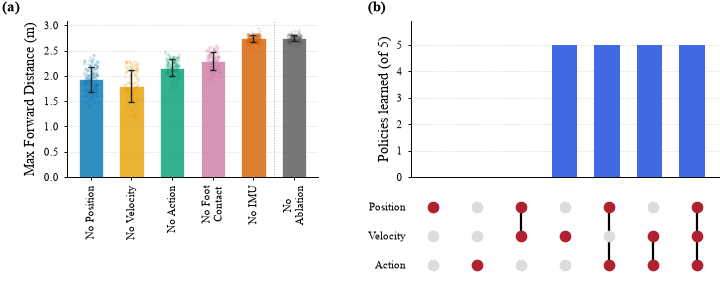

In [4]:
def draw_sensor_loss(ax, scores, order):
    """Panel (a): one bar per ablation, jittered rollouts, +/-1 SD."""
    x = np.arange(len(order))
    colors = [ABLATION_COLOR[a] for a in order]
    means = [scores[a].mean() for a in order]
    sds = [scores[a].std(ddof=1) for a in order]
    width = 0.60
    rng = np.random.default_rng(0)

    ax.bar(x, means, width=width, color=colors, alpha=0.80,
           edgecolor="white", linewidth=0.6, zorder=3)
    ax.errorbar(x, means, yerr=sds, fmt="none", ecolor="#222222",
                elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=5)
    for xi, a in zip(x, order):
        d = scores[a]
        jitter = rng.uniform(-width * 0.28, width * 0.28, size=d.size)
        ax.scatter(xi + jitter, d, color=ABLATION_COLOR[a], alpha=0.18, s=4,
                   linewidths=0, zorder=4)

    # separate the ablations from the un-ablated baseline
    ax.axvline(len(order) - 1.5, color="#aaaaaa", linewidth=0.7, linestyle=":", zorder=7)

    ax.set_xticks(x)
    ax.set_xticklabels([ABLATION_LABEL[a] for a in order], rotation=90)
    ax.set_ylabel("Max Forward Distance (m)", labelpad=5)
    style_axes(ax)


def draw_upset(ax_bars, ax_matrix, learned, complete):
    """Panel (b): bar per sensor subset, dot matrix of which sensors it holds."""
    parse = lambda key: {s.strip() for s in key.split(",")}
    items = sorted(learned.items(), key=lambda kv: (kv[1], len(parse(kv[0]))))
    sets = [parse(k) for k, _ in items]
    values = [v for _, v in items]
    x = np.arange(len(items))

    rows = [s for s in UPSET_ROW_ORDER if s in set().union(*sets)]

    COMPLETE, PARTIAL = "#4169E1", "#9e9e9e"
    ax_bars.bar(x, values, width=0.6, zorder=3,
                color=[COMPLETE if v >= complete else PARTIAL for v in values])
    ax_bars.set_ylabel(f"Policies learned (of {complete})")
    ax_bars.set_ylim(0, complete * 1.18)
    ax_bars.set_xticks([])
    style_axes(ax_bars)

    ACTIVE, INACTIVE = "#b0202f", "#dcdcdc"
    for xi, active in zip(x, sets):
        for r, sensor in enumerate(rows):
            ax_matrix.scatter(xi, r, s=55, zorder=3,
                              color=ACTIVE if sensor in active else INACTIVE)
        on = [r for r, sensor in enumerate(rows) if sensor in active]
        if len(on) >= 2:
            ax_matrix.plot([xi, xi], [min(on), max(on)], color="black", lw=1.6, zorder=2)

    ax_matrix.set_yticks(range(len(rows)))
    ax_matrix.set_yticklabels([UPSET_LABEL[s] for s in rows])
    ax_matrix.set_ylim(len(rows) - 0.5, -0.5)   # first sensor on top
    ax_matrix.set_xlim(-0.5, len(items) - 0.5)
    ax_matrix.set_xticks([])
    style_axes(ax_matrix, grid=None, spines=())
    ax_matrix.tick_params(length=0)


with paper_rc():
    fig = plt.figure(figsize=(PAGE, H_TALL))

    # Both bar axes share one top and one bottom, so their baselines sit at the
    # same level and the two panels stand the same height. What hangs below
    # differs: rotated tick labels on the left, the UpSet matrix on the right.
    BARS_TOP, BARS_BOTTOM = 0.90, 0.38

    gs_a = GridSpec(1, 1, figure=fig, left=0.08, right=0.43,
                    top=BARS_TOP, bottom=BARS_BOTTOM)
    ax_a = fig.add_subplot(gs_a[0])

    gs_b = GridSpec(1, 1, figure=fig, left=0.56, right=0.99,
                    top=BARS_TOP, bottom=BARS_BOTTOM)
    gs_b_matrix = GridSpec(1, 1, figure=fig, left=0.56, right=0.99,
                           top=BARS_BOTTOM - 0.05, bottom=0.04)
    ax_b_bars = fig.add_subplot(gs_b[0])
    ax_b_matrix = fig.add_subplot(gs_b_matrix[0])

    draw_sensor_loss(ax_a, loss, bar_order)
    draw_upset(ax_b_bars, ax_b_matrix, POLICIES_LEARNED, N_POLICIES_TRAINED)

    panel_label(ax_a, "(a)", x=-0.26, y=1.04)
    panel_label(ax_b_bars, "(b)", x=-0.14, y=1.04)

    save_figure(fig, "sensor_loss_upset_combined")
    plt.show()
